In [1]:
from database.db import supabase
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import datetime as dt
from predict import predict_movie, get_metrics, PredictionMetrics
import time
import multiprocessing as mp
import numpy as np
import seaborn as sns

In [2]:
from database.types import Movie

movies_to_get = 150

movies: list[Movie] = (
    supabase.table("movie")
    .select("id, title, boxofficeday(id)")
    .lt("release_date", dt.datetime.now() - dt.timedelta(days=35))
    .gt("budget", 0)
    .order("release_date", desc=True)
    .limit(movies_to_get)
    .execute()
    .data
)

# filter out movies where the boxofficeday count is 1
movies = [movie for movie in movies if len(movie["boxofficeday"]) > 1]

print(f"Got {len(movies)} movies to predict")

Got 148 movies to predict


In [5]:
# make the metrics
metrics: list[PredictionMetrics] = []

# use multiprocessing to speed up the predictions
def predict_movie_wrapper(movie: Movie) -> PredictionMetrics:
    start = time.time()
    print(f"Predicting {movie['title']}")
    predictions = predict_movie(movie['id'], test_days=1)
    metrics = get_metrics(predictions.actual, predictions.predicted)
    end = time.time()
    print(f"Predicted {movie['title']} in {end - start} seconds")
    return metrics

# use a pool of workers to predict the movies
with mp.Pool(mp.cpu_count()) as pool:
    metrics = pool.map(predict_movie_wrapper, movies)


Predicting ChhaavaPredicting Valiant OnePredicting Mickey 17Predicting CompanionPredicting Heart EyesPredicting Snow WhitePredicting Black BagPredicting Dog ManPredicting Den of Thieves 2: PanteraPredicting Better ManPredicting Wolf ManPredicting Kraven the Hunter

Predicting The Lord of the Rings: The War of the RohirrimPredicting Babygirl




Predicting Sonic the Hedgehog 3
Predicting Queer







Most recent date: 2025-02-01
actual=[3199373, 2050081, 735105, 1200359, 701120, 530312, 1061316, 1401027, 538245, 333247, 505466, 335676, 248155, 776306, 617047, 447421, 269860, 194911, 143511, 103178, 178501, 262384, 167932, 63896, 96137, 69163, 50918, 75096, 64361, 28534, 43124, 33878, 19563, 17862, 8856, 12801, 8388, 4493], predicted=[3792044, 2375199, 975475, 1327575, 891931, 695760, 1416755, 2269282, 830579, 527949, 491570, 322399, 296114, 1592963, 1289791, 1072112, 838982, 368188, 225148, 203411, 405209, 662577, 432169, 107022, 156089, 91962, 81253, 191448, 326862, 197952, 60721, 6667

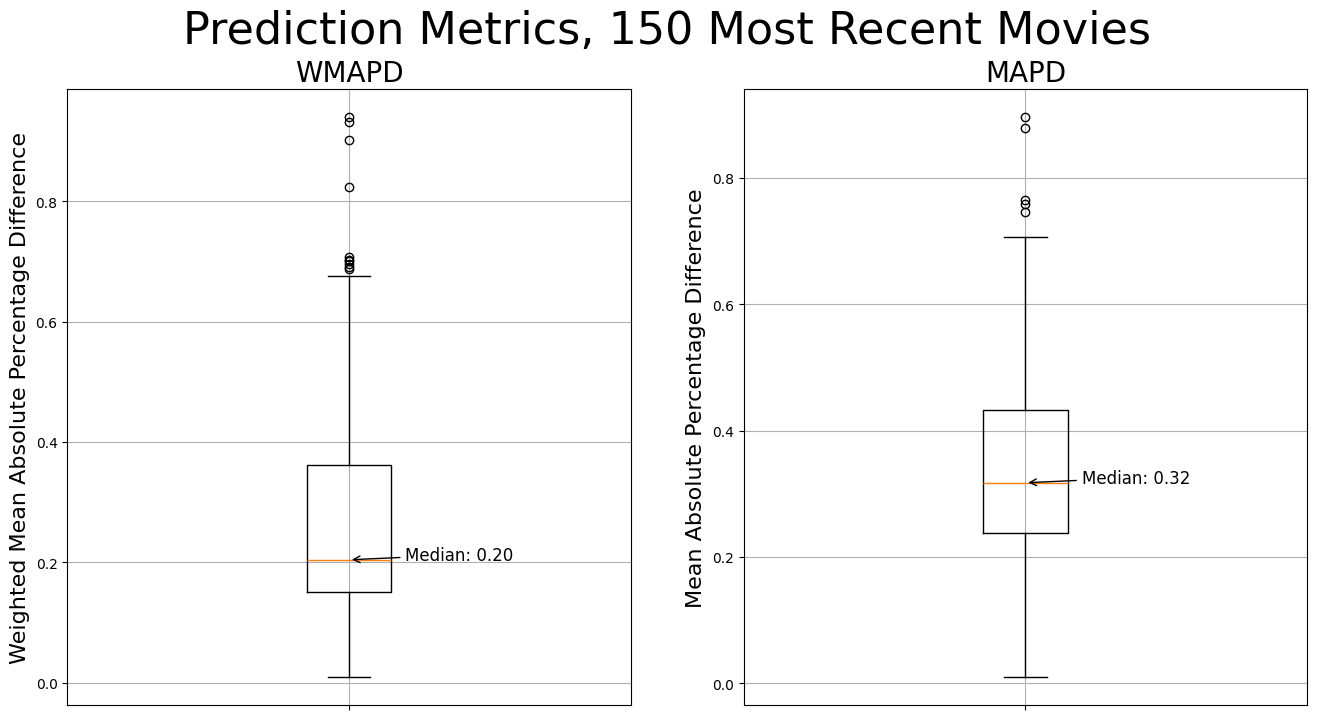

In [5]:
# boxplot for each metric
# 5 subplots
axis_count = 2

fig, axs = plt.subplots(1, axis_count, figsize=(8 + axis_count * 4, 4 + axis_count * 2))
plt.suptitle(f"Prediction Metrics, {movies_to_get} Most Recent Movies", fontsize=32)
fig.subplots_adjust(hspace=2)

def plot_metric(ax: Axes, metric: list[float], title: str, ylabel: str):
    ax.boxplot(metric)
    ax.set_title(title, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xticklabels([""])
    ax.grid()

# annotate the median of each boxplot
for i, ax in enumerate(axs):
    if i == 0:
        metric = [m.wmapd for m in metrics]
        plot_metric(ax, metric, "WMAPD", "Weighted Mean Absolute Percentage Difference")
    elif i == 1:
        metric = [m.mapd for m in metrics]
        plot_metric(ax, metric, "MAPD", "Mean Absolute Percentage Difference")
    elif i == 2:
        metric = [m.mape for m in metrics]
        plot_metric(ax, metric, "MAPE", "Mean Absolute Percentage Error")
    elif i == 3:
        metric = [m.rmse for m in metrics]
        plot_metric(ax, metric, "RMSE", "Root Mean Squared Error")
    median = np.median(metric)
    ax.annotate(
        f"Median: {median:.2f}",
        xy=(1, median),
        xytext=(1.1, median),
        arrowprops=dict(arrowstyle="->"),
        fontsize=12,
    )

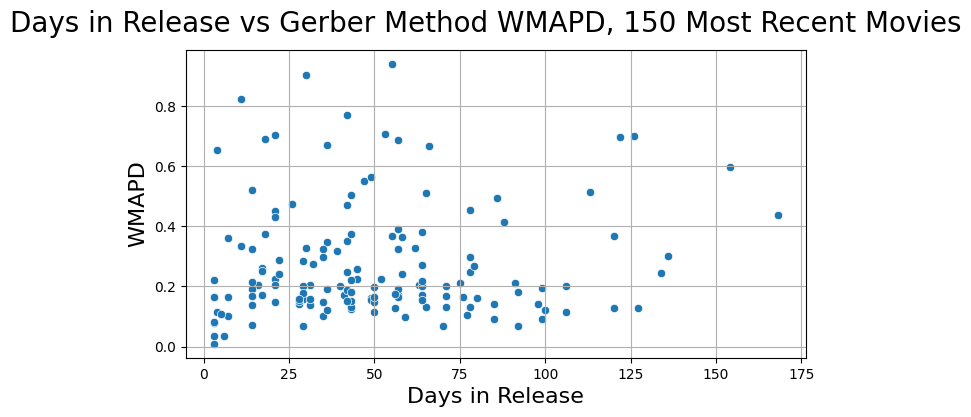

In [10]:
# scatter plot of days in release vs wmapd
fig = plt.figure(figsize=(8, 4))
plt.suptitle(f"Days in Release vs Gerber Method WMAPD, {movies_to_get} Most Recent Movies", fontsize=20)
sns.scatterplot(
    x=[len(movie["boxofficeday"]) for movie in movies],
    y=[m.wmapd for m in metrics],
)
plt.xlabel("Days in Release", fontsize=16)
plt.ylabel("WMAPD", fontsize=16)
plt.grid()